In [6]:
## STEP 1 IMPORT LIBRARY

import os
import pandas as pd
import numpy as np
import librosa
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score,
                             classification_report)
import warnings
warnings.filterwarnings('ignore')

In [7]:
## STEP 2 LOAD DATASET

# Path ke file metadata dan folder audio
metadata_path = 'validated.tsv'
audio_folder = 'clips'

# Membaca metadata
df = pd.read_csv(metadata_path, sep='\t')
print(f"Jumlah data awal: {len(df)}")
print(df.head())

Jumlah data awal: 30331
                                           client_id  \
0  00f046cd1abd7e4ed354c2d97b67aceee8deb20bf53e5c...   
1  018b3f1a0a941a5b881a886830d9f133402ed66409489a...   
2  025f07759891360d312521dd83679fa6a233b9d7aa9d4a...   
3  0a4e7e60acc2a6145fc2589e6abb81e41e430cea0611bd...   
4  0a64c046530244b7507d4404575e8f673613c939ad6fac...   

                           path  \
0  common_voice_id_39599471.mp3   
1  common_voice_id_32165882.mp3   
2  common_voice_id_27657418.mp3   
3  common_voice_id_23033570.mp3   
4  common_voice_id_40088845.mp3   

                                         sentence_id  \
0  05e82b3c6f238b34985f158c4b63a8a9fda0382f1bd798...   
1  dd457d82f974202742803bf426f129d339fb1cf2217876...   
2  34f56b62e91fbbffeb7df499d4486aaa9f6d963a93d57f...   
3  ecee266f978e8296fc17d2bcfa744429165db882dbe5fd...   
4  67125efffe8d90c1147d6d609ca9e041f17b1a78b6a3d2...   

                                            sentence  sentence_domain  \
0                D

In [8]:
## STEP 3 FILTER DATASET

# Filter hanya dua kelas yang diinginkan
df_filtered = df[df['gender'].isin(['male_masculine', 'female_feminine'])].copy()
print(f"Jumlah data setelah filter: {len(df_filtered)}")
print("Distribusi gender:")
print(df_filtered['gender'].value_counts())

Jumlah data setelah filter: 21587
Distribusi gender:
gender
male_masculine     13983
female_feminine     7604
Name: count, dtype: int64


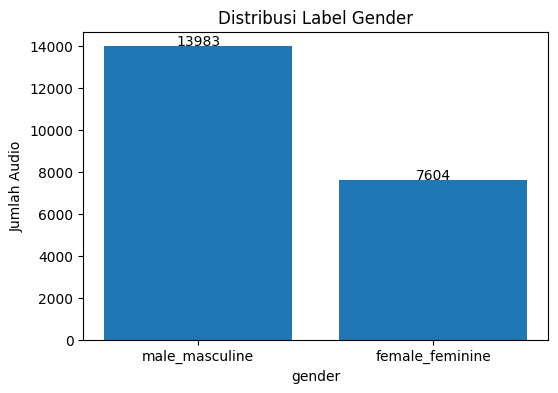

In [9]:
import matplotlib.pyplot as plt

label_counts = df["gender"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(label_counts.index, label_counts.values)
plt.title("Distribusi Label Gender")
plt.xlabel("gender")
plt.ylabel("Jumlah Audio")

for i, v in enumerate(label_counts.values):
    plt.text(i, v + 30, str(v), ha='center')

plt.show()